# Metrics Comparison Histogram Analysis

This notebook loads the benchmark metrics comparison data and creates histograms to visualize the distribution of performance and RDF metrics across different generators.

## 1. Import Required Libraries

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 2. Load CSV Data

In [82]:
# Load the metrics comparison CSV
df = pd.read_csv('metrics_comparison.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head()

Dataset Shape: (16, 14)

Column Names:
['Generator', 'Run_ID', 'Perf_Throughput', 'Perf_Total_Triples', 'Perf_Execution_Time', 'RDF_Triples', 'RDF_Subjects', 'RDF_Predicates', 'RDF_Objects', 'RDF_Classes', 'RDF_Mean_Outdegree', 'RDF_Mean_Indegree', 'RDF_Coherence', 'RDF_Type_Coverage_Avg']

First few rows:


,Generator,Run_ID,Perf_Throughput,Perf_Total_Triples,Perf_Execution_Time,RDF_Triples,RDF_Subjects,RDF_Predicates,RDF_Objects,RDF_Classes,RDF_Mean_Outdegree,RDF_Mean_Indegree,RDF_Coherence,RDF_Type_Coverage_Avg
0,BSBM_HIGH_COHERENCE,run_1,1.010056e+06,35272182,34.92,35272182,3204145,40,5886014,2019,11.008298,5.992541,0.943216,0.816810
1,BSBM_LOW_COHERENCE,run_1,8.800845e+05,17686178,20.10,17686178,1601677,40,3149589,739,11.042288,5.615392,0.946669,0.817607
2,GAIA_LUBM_HIGH_COHERENCE,run_1,5.803940e+05,10320000,21.24,12327122,3440095,32,1046971,50,3.583367,11.774082,0.390621,0.589110
3,GAIA_LUBM_LOW_COHERENCE,run_1,5.030697e+05,10320000,15.75,7925254,3440095,32,1045103,50,2.303789,7.583228,0.324152,0.604603
4,LINKGEN_LUBM_HIGH_COHERENCE,run_1,7.096039e+03,102145,15.81,112160,719,25,51,31,155.994437,2199.215686,0.625299,0.974869


## 3. Data Preprocessing

In [83]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Extract coherence level (HIGH/LOW) from Generator name
df['Coherence_Level'] = df['Generator'].apply(lambda x: 'HIGH' if 'HIGH' in x else 'LOW')

# Extract base generator name (without coherence suffix)
df['Base_Generator'] = df['Generator'].apply(lambda x: x.replace('_HIGH_COHERENCE', '').replace('_LOW_COHERENCE', ''))

# Display summary statistics
print("\nSummary Statistics:")
df.describe()

Missing Values:
Generator                0
Run_ID                   0
Perf_Throughput          0
Perf_Total_Triples       0
Perf_Execution_Time      0
RDF_Triples              0
RDF_Subjects             0
RDF_Predicates           0
RDF_Objects              0
RDF_Classes              0
RDF_Mean_Outdegree       0
RDF_Mean_Indegree        0
RDF_Coherence            0
RDF_Type_Coverage_Avg    0
dtype: int64

Summary Statistics:


,Perf_Throughput,Perf_Total_Triples,Perf_Execution_Time,RDF_Triples,RDF_Subjects,RDF_Predicates,RDF_Objects,RDF_Classes,RDF_Mean_Outdegree,RDF_Mean_Indegree,RDF_Coherence,RDF_Type_Coverage_Avg
count,1.600000e+01,1.600000e+01,16.000000,1.600000e+01,1.600000e+01,16.000000,1.600000e+01,16.000000,16.000000,16.000000,16.000000,16.000000
mean,2.492438e+05,5.645538e+06,23.478750,5.852257e+06,9.417620e+05,24.000000,8.601486e+05,196.437500,15.430927,292.920227,0.750040,0.824454
std,3.413569e+05,9.418031e+06,10.422941,9.442371e+06,1.295395e+06,9.514901,1.561338e+06,517.629593,37.576921,779.850691,0.261790,0.184602
min,1.398833e+03,9.436000e+03,6.180000,1.767700e+04,7.190000e+02,14.000000,4.900000e+01,15.000000,2.303789,2.151093,0.324152,0.461348
25%,1.746500e+04,3.997592e+05,15.795000,4.041380e+05,1.024498e+05,17.000000,7.029575e+04,15.000000,3.799439,5.898254,0.475110,0.747215
50%,3.319620e+04,1.085645e+06,23.455000,1.085645e+06,1.884450e+05,19.500000,1.687465e+05,23.000000,6.353589,8.543478,0.874333,0.881351
75%,5.035751e+05,7.746482e+06,28.182500,7.498734e+06,1.268444e+06,32.000000,9.072875e+05,50.250000,7.717500,12.054415,0.958446,0.978374
max,1.010056e+06,3.527218e+07,42.330000,3.527218e+07,3.440095e+06,40.000000,5.886014e+06,2019.000000,155.994437,2378.612245,0.998148,0.996667


## 4. Create Histograms for Performance Metrics

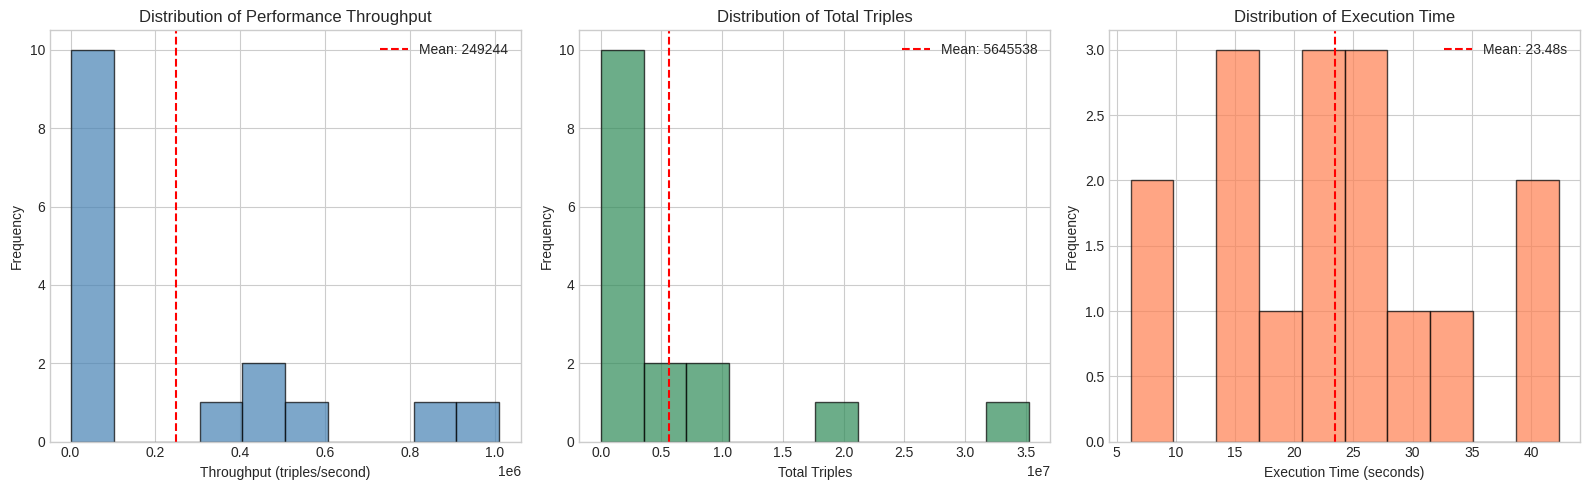

In [84]:
# Create histograms for Performance Metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Throughput histogram
axes[0].hist(df['Perf_Throughput'], bins=10, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Throughput (triples/second)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Performance Throughput')
axes[0].axvline(df['Perf_Throughput'].mean(), color='red', linestyle='--', label=f'Mean: {df["Perf_Throughput"].mean():.0f}')
axes[0].legend()

# Total Triples histogram
axes[1].hist(df['Perf_Total_Triples'], bins=10, edgecolor='black', alpha=0.7, color='seagreen')
axes[1].set_xlabel('Total Triples')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Total Triples')
axes[1].axvline(df['Perf_Total_Triples'].mean(), color='red', linestyle='--', label=f'Mean: {df["Perf_Total_Triples"].mean():.0f}')
axes[1].legend()

# Execution Time histogram
axes[2].hist(df['Perf_Execution_Time'], bins=10, edgecolor='black', alpha=0.7, color='coral')
axes[2].set_xlabel('Execution Time (seconds)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of Execution Time')
axes[2].axvline(df['Perf_Execution_Time'].mean(), color='red', linestyle='--', label=f'Mean: {df["Perf_Execution_Time"].mean():.2f}s')
axes[2].legend()

plt.tight_layout()
plt.show()

## 5. Create Histograms for RDF Metrics

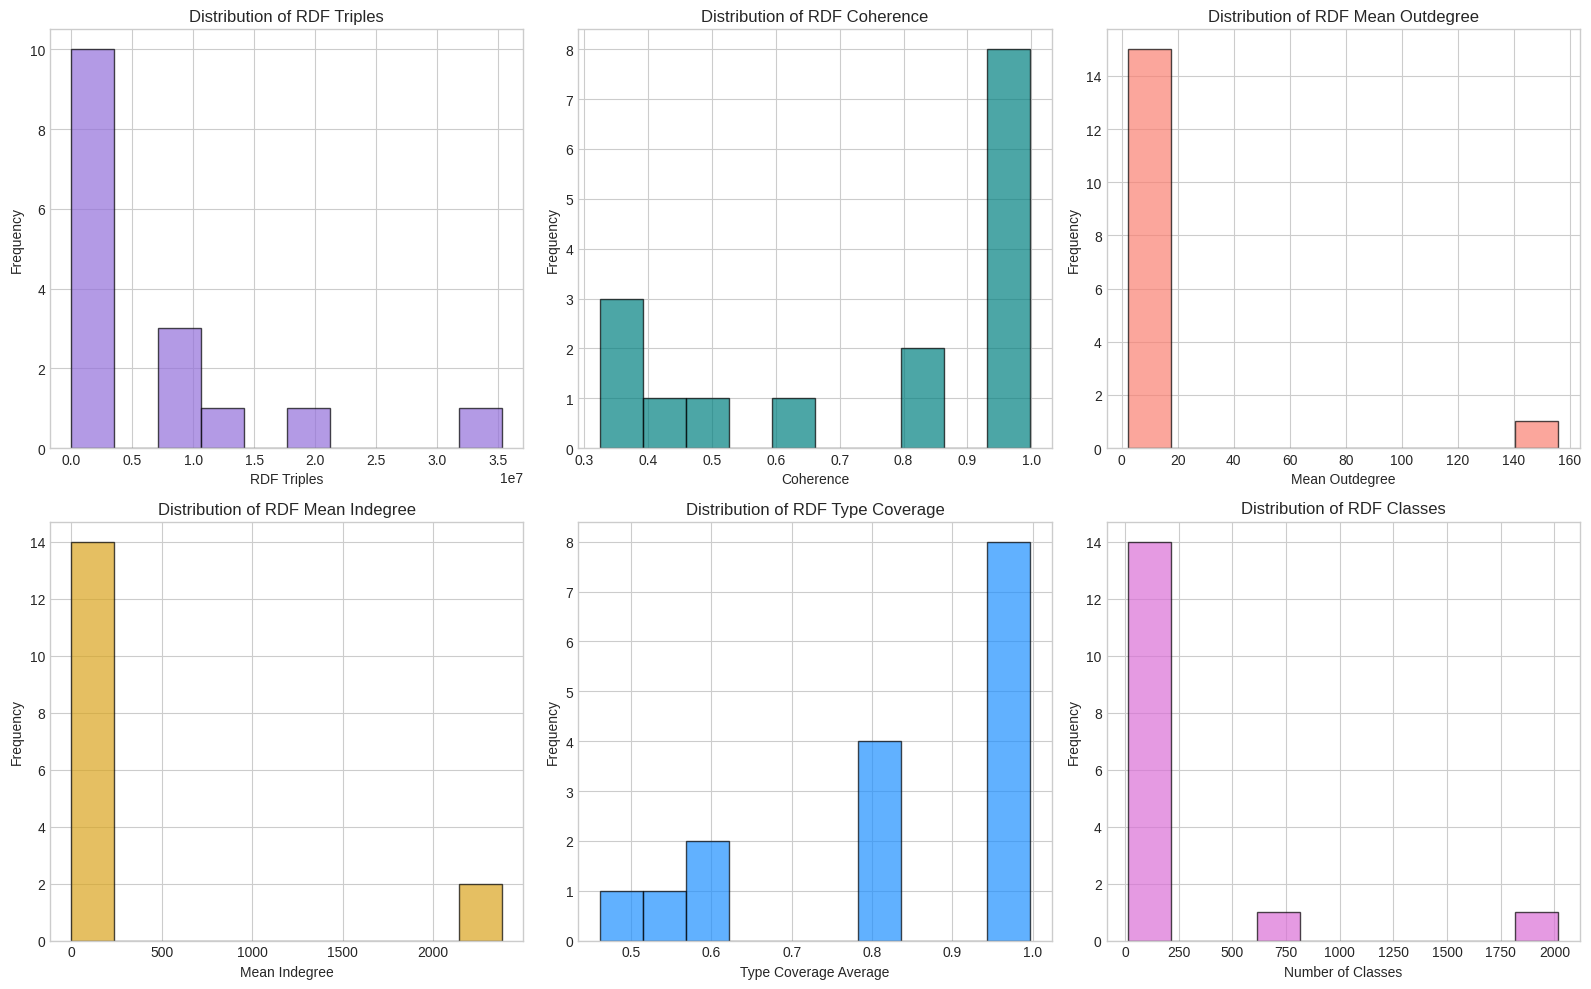

In [85]:
# Create histograms for RDF Metrics
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# RDF Triples histogram
axes[0, 0].hist(df['RDF_Triples'], bins=10, edgecolor='black', alpha=0.7, color='mediumpurple')
axes[0, 0].set_xlabel('RDF Triples')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of RDF Triples')

# RDF Coherence histogram
axes[0, 1].hist(df['RDF_Coherence'], bins=10, edgecolor='black', alpha=0.7, color='teal')
axes[0, 1].set_xlabel('Coherence')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of RDF Coherence')

# RDF Mean Outdegree histogram
axes[0, 2].hist(df['RDF_Mean_Outdegree'], bins=10, edgecolor='black', alpha=0.7, color='salmon')
axes[0, 2].set_xlabel('Mean Outdegree')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Distribution of RDF Mean Outdegree')

# RDF Mean Indegree histogram
axes[1, 0].hist(df['RDF_Mean_Indegree'], bins=10, edgecolor='black', alpha=0.7, color='goldenrod')
axes[1, 0].set_xlabel('Mean Indegree')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of RDF Mean Indegree')

# RDF Type Coverage histogram
axes[1, 1].hist(df['RDF_Type_Coverage_Avg'], bins=10, edgecolor='black', alpha=0.7, color='dodgerblue')
axes[1, 1].set_xlabel('Type Coverage Average')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of RDF Type Coverage')

# RDF Classes histogram
axes[1, 2].hist(df['RDF_Classes'], bins=10, edgecolor='black', alpha=0.7, color='orchid')
axes[1, 2].set_xlabel('Number of Classes')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Distribution of RDF Classes')

plt.tight_layout()
plt.show()

## 6. Create Grouped Histograms by Generator

In [86]:

# Shared settings for all grouped bar charts
TITLE_SIZE = 12
LABEL_SIZE = 10
TICK_SIZE = 9
LEGEND_SIZE = 9
FIG_W = 7
FIG_H = 5

colors = {'HIGH': 'steelblue', 'LOW': 'coral'}
generators = df['Base_Generator'].unique()
x = np.arange(len(generators))
width = 0.35


### 6.1 Throughput by Generator (Broken Y-Axis)

Saved: output_charts/throughput_by_generator.pdf


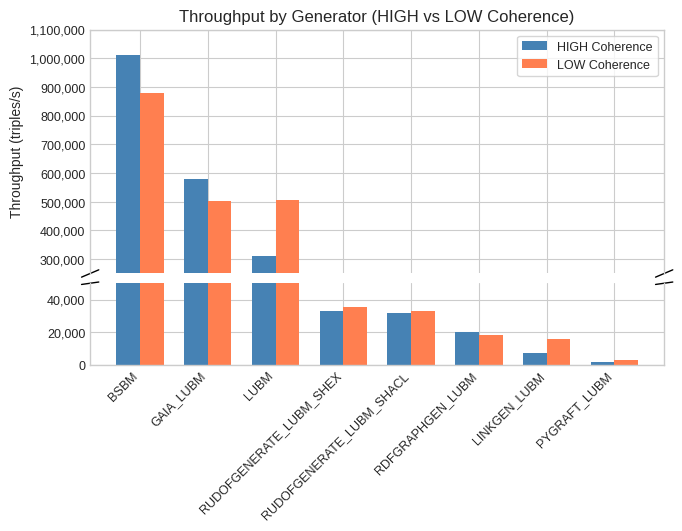

In [93]:

# Throughput by Generator — Broken Y-Axis
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(FIG_W, FIG_H),
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.06}
)

high_throughput = df[df['Coherence_Level'] == 'HIGH'].set_index('Base_Generator')['Perf_Throughput']
low_throughput  = df[df['Coherence_Level'] == 'LOW'].set_index('Base_Generator')['Perf_Throughput']

# Sort generators by HIGH throughput descending (smallest on the right)
sorted_gens_tp = sorted(generators, key=lambda g: high_throughput.get(g, 0), reverse=True)
x_tp = np.arange(len(sorted_gens_tp))
high_vals = [high_throughput.get(g, 0) for g in sorted_gens_tp]
low_vals  = [low_throughput.get(g, 0) for g in sorted_gens_tp]

ax_top.bar(x_tp - width/2, high_vals, width, label='HIGH Coherence', color=colors['HIGH'])
ax_top.bar(x_tp + width/2, low_vals,  width, label='LOW Coherence',  color=colors['LOW'])
ax_bot.bar(x_tp - width/2, high_vals, width, color=colors['HIGH'])
ax_bot.bar(x_tp + width/2, low_vals,  width, color=colors['LOW'])

ax_top.set_ylim(250_000, 1_100_000)
ax_bot.set_ylim(0, 50_000)

ax_top.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax_bot.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))

ax_top.spines['bottom'].set_visible(False)
ax_bot.spines['top'].set_visible(False)
ax_top.tick_params(axis='x', bottom=False)
plt.setp(ax_top.get_xticklabels(), visible=False)

# Diagonal break marks
d = 0.015
kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False, linewidth=1)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)
kwargs.update(transform=ax_bot.transAxes)
ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

ax_bot.set_xticks(x_tp)
ax_bot.set_xticklabels(sorted_gens_tp, rotation=45, ha='right', fontsize=TICK_SIZE)
ax_top.tick_params(axis='y', labelsize=TICK_SIZE)
ax_bot.tick_params(axis='y', labelsize=TICK_SIZE)
ax_top.set_ylabel('Throughput (triples/s)', fontsize=LABEL_SIZE)
ax_top.set_title('Throughput by Generator (HIGH vs LOW Coherence)', fontsize=TITLE_SIZE)
ax_top.legend(fontsize=LEGEND_SIZE, loc='upper right', frameon=True)

fig.subplots_adjust(left=0.14, right=0.96, bottom=0.25, top=0.92)
fig.savefig('output_charts/throughput_by_generator.pdf', format='pdf', bbox_inches='tight')
print('Saved: output_charts/throughput_by_generator.pdf')

plt.show()

### 6.2 RDF Coherence by Generator

Saved: output_charts/coherence_by_generator.pdf


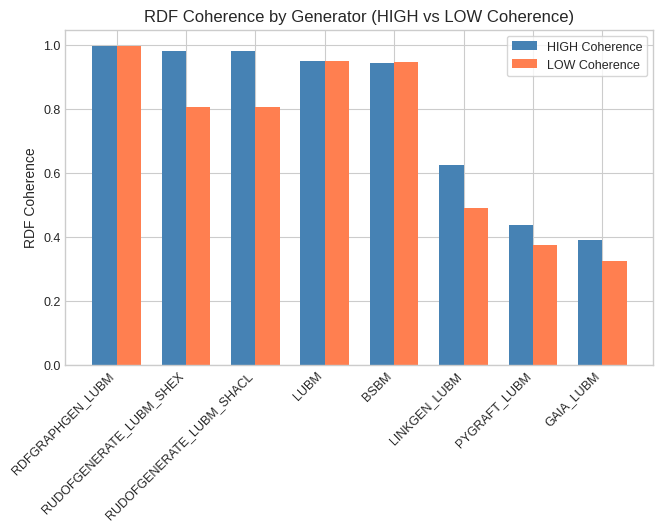

In [91]:

# RDF Coherence by Generator
fig, ax_coh = plt.subplots(figsize=(FIG_W, FIG_H))

high_coherence = df[df['Coherence_Level'] == 'HIGH'].set_index('Base_Generator')['RDF_Coherence']
low_coherence  = df[df['Coherence_Level'] == 'LOW'].set_index('Base_Generator')['RDF_Coherence']

# Sort generators by HIGH coherence descending (smallest on the right)
sorted_gens = sorted(generators, key=lambda g: high_coherence.get(g, 0), reverse=True)
x_coh = np.arange(len(sorted_gens))

ax_coh.bar(x_coh - width/2, [high_coherence.get(g, 0) for g in sorted_gens], width, label='HIGH Coherence', color=colors['HIGH'])
ax_coh.bar(x_coh + width/2, [low_coherence.get(g, 0) for g in sorted_gens],  width, label='LOW Coherence',  color=colors['LOW'])
ax_coh.set_ylabel('RDF Coherence', fontsize=LABEL_SIZE)
ax_coh.set_title('RDF Coherence by Generator (HIGH vs LOW Coherence)', fontsize=TITLE_SIZE)
ax_coh.set_xticks(x_coh)
ax_coh.set_xticklabels(sorted_gens, rotation=45, ha='right', fontsize=TICK_SIZE)
ax_coh.tick_params(axis='y', labelsize=TICK_SIZE)
ax_coh.legend(fontsize=LEGEND_SIZE, loc='upper right', frameon=True)

fig.subplots_adjust(left=0.12, right=0.96, bottom=0.25, top=0.92)
fig.savefig('output_charts/coherence_by_generator.pdf', format='pdf', bbox_inches='tight')
print('Saved: output_charts/coherence_by_generator.pdf')

plt.show()

### 6.3 Execution Time by Generator

Saved: output_charts/execution_time_by_generator.pdf


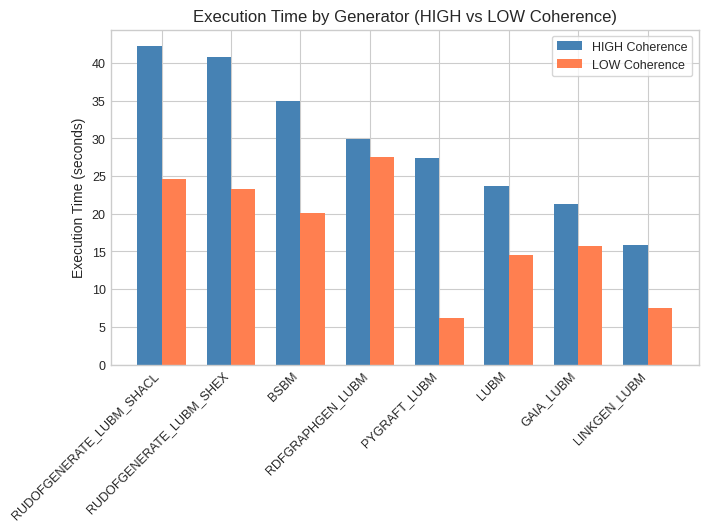

In [96]:

# Execution Time by Generator
fig, ax_time = plt.subplots(figsize=(FIG_W, FIG_H))

high_exec_time = df[df['Coherence_Level'] == 'HIGH'].set_index('Base_Generator')['Perf_Execution_Time']
low_exec_time  = df[df['Coherence_Level'] == 'LOW'].set_index('Base_Generator')['Perf_Execution_Time']

# Sort generators by HIGH execution time descending (smallest on the right)
sorted_gens_et = sorted(generators, key=lambda g: high_exec_time.get(g, 0), reverse=True)
x_et = np.arange(len(sorted_gens_et))

ax_time.bar(x_et - width/2, [high_exec_time.get(g, 0) for g in sorted_gens_et], width, label='HIGH Coherence', color=colors['HIGH'])
ax_time.bar(x_et + width/2, [low_exec_time.get(g, 0) for g in sorted_gens_et],  width, label='LOW Coherence',  color=colors['LOW'])
ax_time.set_ylabel('Execution Time (seconds)', fontsize=LABEL_SIZE)
ax_time.set_title('Execution Time by Generator (HIGH vs LOW Coherence)', fontsize=TITLE_SIZE)
ax_time.set_xticks(x_et)
ax_time.set_xticklabels(sorted_gens_et, rotation=45, ha='right', fontsize=TICK_SIZE)
ax_time.tick_params(axis='y', labelsize=TICK_SIZE)
ax_time.legend(fontsize=LEGEND_SIZE, loc='upper right', frameon=True)

fig.subplots_adjust(left=0.12, right=0.96, bottom=0.25, top=0.92)
fig.savefig('output_charts/execution_time_by_generator.pdf', format='pdf', bbox_inches='tight')
print('Saved: output_charts/execution_time_by_generator.pdf')

plt.show()

BSBM: 0.9432
GAIA_LUBM: 0.3906
LINKGEN_LUBM: 0.6253
LUBM: 0.9504
PYGRAFT_LUBM: 0.4358
RDFGRAPHGEN_LUBM: 0.9981
RUDOFGENERATE_LUBM_SHACL: 0.9825
RUDOFGENERATE_LUBM_SHEX: 0.9825
